<a href="https://colab.research.google.com/github/Anne-And/CV1/blob/main/AI_ML_task_fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install roboflow ultralytics rasterio numpy matplotlib opencv-python-headless \
            scikit-image shapely geopandas pyproj pillow --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 56.0 MB/s eta 0:00:00


In [2]:
import os
import cv2
import heapq
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
from skimage.morphology import dilation, disk
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

dataset_path = "/content/drive/MyDrive/Chandrayaan 2 OHRC Lunar Crater Dataset.v4i.yolov11"
!ls "{dataset_path}"


data.yaml  README.dataset.txt  README.roboflow.txt  train  valid


In [5]:

model = YOLO("yolov8n.pt")

results_train = model.train(
    data=f"{dataset_path}/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16
)


Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Chandrayaan 2 OHRC Lunar Crater Dataset.v4i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=

In [6]:
OHRC_PATH = "/content/drive/MyDrive/isro.png"
img_raw = cv2.imread(OHRC_PATH, cv2.IMREAD_GRAYSCALE)


if img_raw is None:
    raise FileNotFoundError(f"Could not load image at: {OHRC_PATH}. Check the path.")

h, w = img_raw.shape
print("OHRC Image Shape:", img_raw.shape)


OHRC Image Shape: (898, 1795)


In [14]:

trained_model = YOLO("runs/detect/train/weights/best.pt")
detection_results = trained_model.predict(source=OHRC_PATH, imgsz=640, conf=0.25, verbose=False)


In [15]:
# Build obstacle mask from detections
obstacle_mask = np.zeros((h, w), dtype=np.uint8)
for r in detection_results:  # FIX: was 'results' which shadowed train results
    for box in r.boxes.xyxy.cpu().numpy():
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(obstacle_mask, (x1, y1), (x2, y2), 1, -1)

obstacle_mask = dilation(obstacle_mask, disk(3))


In [9]:
# Compute shadow mask and terrain roughness
SHADOW_THRESHOLD = np.percentile(img_raw, 10)
shadow_mask = np.zeros_like(img_raw, dtype=np.float32)
shadow_mask[img_raw < SHADOW_THRESHOLD] = 1.0
shadow_mask = uniform_filter(shadow_mask, size=5)

sobelx = cv2.Sobel(img_raw.astype(np.float32), cv2.CV_32F, 1, 0, ksize=5)
sobely = cv2.Sobel(img_raw.astype(np.float32), cv2.CV_32F, 0, 1, ksize=5)
H_rough = np.sqrt(sobelx**2 + sobely**2)
H_rough_norm = (H_rough - H_rough.min()) / (H_rough.max() - H_rough.min() + 1e-6)


In [10]:
# Build traversability cost map
W_ROUGHNESS = 5.0
W_SHADOW = 10.0
INF_COST = 1e6

cost_map = np.ones_like(img_raw, dtype=np.float32)
cost_map += H_rough_norm * W_ROUGHNESS
cost_map += shadow_mask * W_SHADOW
cost_map[obstacle_mask > 0] = INF_COST


In [11]:
# A* pathfinding (heapq imported at top of notebook)

def neighbors(r, c, h, w):
    """Generates neighbors and their distance factors."""
    moves = [
        (-1, 0, 1.0), (1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0),
        (-1, -1, 1.414), (-1, 1, 1.414), (1, -1, 1.414), (1, 1, 1.414)
    ]
    for dr, dc, dist_factor in moves:
        nr, nc = r + dr, c + dc
        if 0 <= nr < h and 0 <= nc < w:
            yield nr, nc, dist_factor

def astar_optimized(start, goal, costmap):
    """A* search optimized using heapq (Priority Queue)."""
    sr, sc = start
    gr, gc = goal
    h, w = costmap.shape
    open_set = [(0, sr, sc)]
    gscore = {(sr, sc): 0}
    came_from = {}

    while open_set:
        f_current, r_current, c_current = heapq.heappop(open_set)
        current = (r_current, c_current)

        if current == (gr, gc):
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for nbr_r, nbr_c, dist_factor in neighbors(*current, h, w):
            nbr = (nbr_r, nbr_c)
            transition_cost = costmap[nbr] * dist_factor
            tr = gscore[current] + transition_cost

            if tr < gscore.get(nbr, INF_COST):
                came_from[nbr] = current
                gscore[nbr] = tr
                h_score = np.hypot(nbr_r - gr, nbr_c - gc)
                f = tr + h_score
                heapq.heappush(open_set, (f, nbr_r, nbr_c))

    return None


In [12]:
# Run A* pathfinding
LANDING_PIXEL = (500, 500)  # adjust after inspecting your image
MIN_PATH_LENGTH_M = 100.0
GSD = 0.3  # Ground Sampling Distance in metres/pixel
NUM_STOPS = 10

min_dist_px = int(MIN_PATH_LENGTH_M / GSD)
goal_pixel = (min(LANDING_PIXEL[0] + 50, h-1), min(LANDING_PIXEL[1] + min_dist_px, w-1))

path = astar_optimized(LANDING_PIXEL, goal_pixel, cost_map)

if path is None:
    raise RuntimeError("A* found no path. Try adjusting LANDING_PIXEL or goal_pixel.")

# FIX: length_m was used in the plot title but never calculated
length_m = len(path) * GSD
print(f"Path found with {len(path)} steps, approx {length_m:.2f} m")


Path found with 335 steps, approx 100.50 m


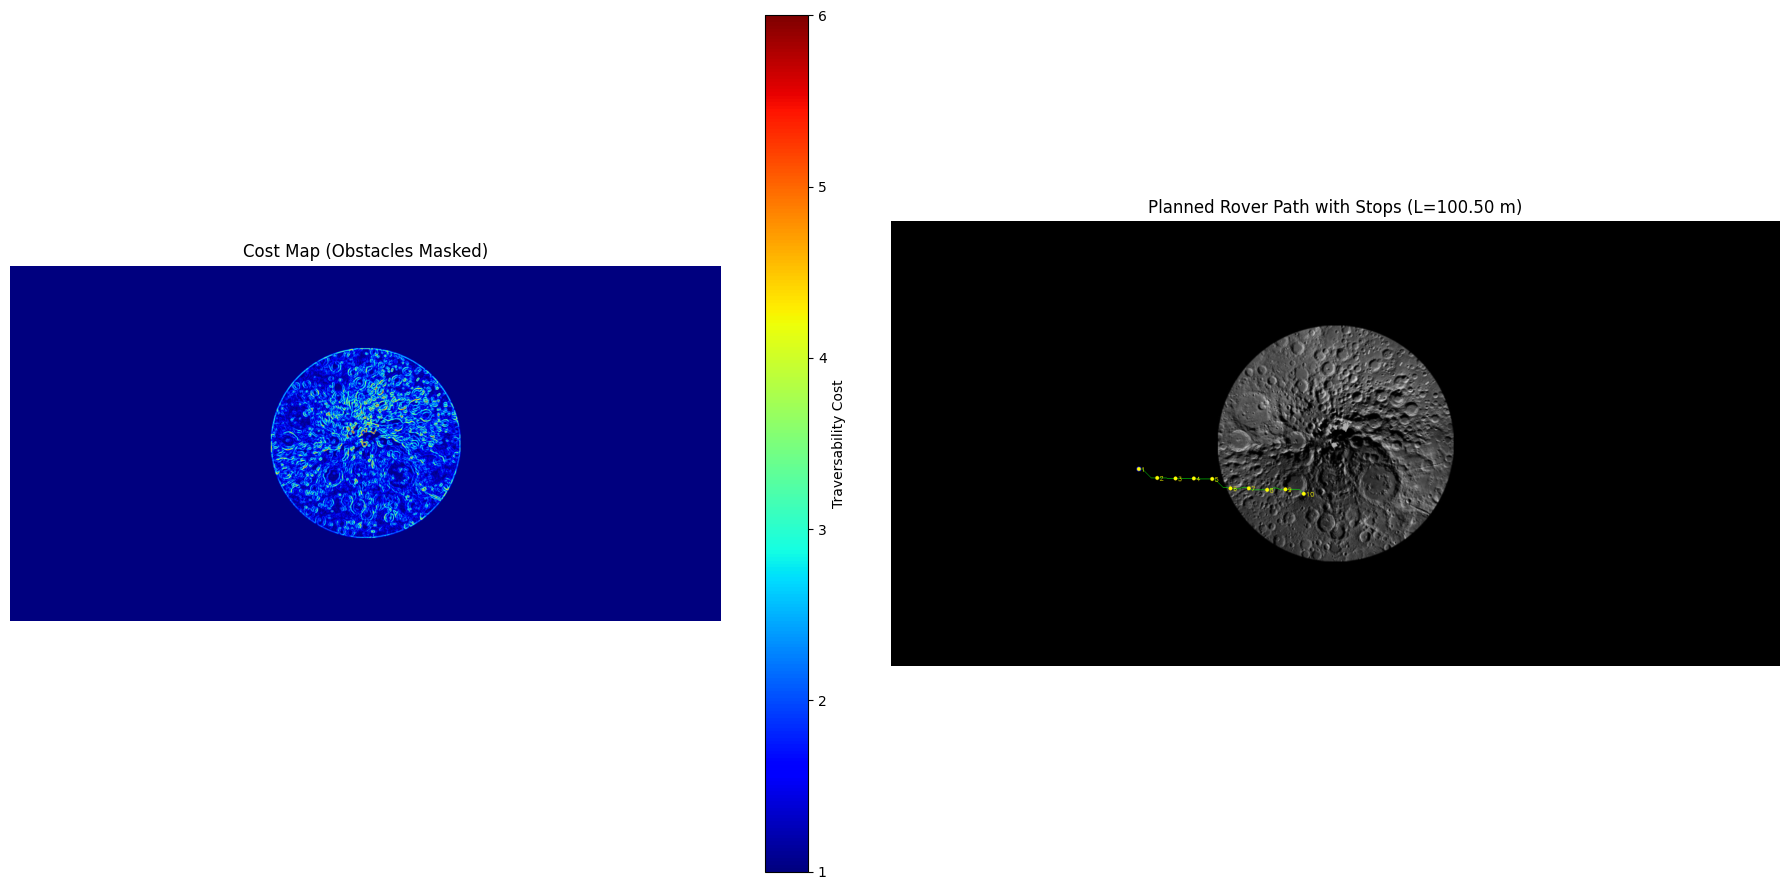


Code execution complete.


In [13]:
# Visualize cost map and planned path
plt.figure(figsize=(18, 9))
plt.subplot(1, 2, 1)
cost_vis = np.copy(cost_map)
cost_vis[cost_vis == INF_COST] = np.nan
plt.imshow(cost_vis, cmap='jet')
plt.title("Cost Map (Obstacles Masked)")
plt.colorbar(label='Traversability Cost')
plt.axis("off")

# Path on original image
indices = np.linspace(0, len(path)-1, NUM_STOPS, dtype=int)
stops = [path[i] for i in indices]

vis = cv2.cvtColor(img_raw, cv2.COLOR_GRAY2BGR)
for r, c in path:
    vis[r, c] = (0, 255, 0)  # Green path
cv2.circle(vis, (LANDING_PIXEL[1], LANDING_PIXEL[0]), 5, (255, 0, 0), -1)  # Blue start
for i, (r, c) in enumerate(stops):
    cv2.circle(vis, (c, r), 4, (0, 255, 255), -1)  # Yellow stops
    cv2.putText(vis, str(i+1), (c+5, r+5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)

plt.subplot(1, 2, 2)
plt.imshow(vis[..., ::-1])
plt.title(f"Planned Rover Path with Stops (L={length_m:.2f} m)")
plt.axis("off")
plt.tight_layout()
plt.show()

print("\nCode execution complete.")
